In [ ]:
# Packages
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [ ]:
# Fetch data
df=pd.read_csv("../spiff_data-2.csv")
mask=df==1000
df[mask]=pd.NA
df=df.dropna()
df=df.drop(columns=['Unnamed: 0', 'day'])

# Risk free rate
r = 0.03  

In [ ]:
def log_returns(portfolie_value, period=1):
    maturity=len(portfolie_value)
    log_returns=np.log(portfolie_value[1:maturity]/portfolie_value[0:maturity-1])

    #annulize 
    log_returns=period*log_returns
    return log_returns
 
def SharpeRatio(log_return, r, period=1, low_volatilty_asset_adjustment=0):

    log_return = np.asarray(log_return)
    log_return=log_return[~np.isnan(log_return)]
    
    mu_hat = np.mean(log_return)
    sigma_hat = np.std(log_return)

    # Add a small epsilon to compensate for near-zero volatility. 
    # This is only used in the grid search optimisation in the channel breakout strategy,
    # where some parameter combinations may lead to very low volatility.
    sigma_hat+=low_volatilty_asset_adjustment

    daily_SharpeRatio=(mu_hat - r/252) / sigma_hat

    # Return SharpeRatio "annualized" to the correct period. 
    return np.sqrt(period)*daily_SharpeRatio

In [4]:
# Channel breakout strategy


def channel_breakout_trade(price_time_series,c_channel_width,x_trend_requirement,k_days_of_holding_stock,
                           time_span_for_comparison, sustained_trend_requirement,r,initial_portfolio_value,
                           allow_short_bool=False, allow_multiple_positions=True):
    count_low=0
    count_high=0
    maturity=len(price_time_series)
    trading_volume=1

    money_account=np.zeros(maturity) # Money account, initially holding all portfolio value. 
    money_account[0]=initial_portfolio_value
   
    stock_position=np.zeros(maturity) # Store stock positions. 

    exit_position_signal=np.zeros(maturity) # Bookkeping for when to exit positions, -1 for selling (exiting long pos,), +1 for buying (exiting short pos.)


    for idx in range(1,maturity):
        # idx represents time

        money_account[idx]=money_account[idx-1] # Carry over money, adjust below if trades. 
        
        current_price=price_time_series[idx]

        if idx > time_span_for_comparison: # This is when we can start the channel trade. 
            stock_position[idx]=stock_position[idx-1] # Hold the same amount of stock, adjust below if enter/exit stock positions

            stock_price_high=max(price_time_series[idx-time_span_for_comparison-1:idx-1])
            stock_price_low=min(price_time_series[idx-time_span_for_comparison-1:idx-1])
            
            if stock_price_high<= (1+c_channel_width)*stock_price_low and stock_price_low >=(1-c_channel_width)*stock_price_high: # Check if we are in a price channel 

                upper_channel_bound=stock_price_low*(1+c_channel_width)
                lower_channel_bound=stock_price_high*(1-c_channel_width)

                # Case with a neative trend, potentially a short position scenario 
                if current_price <= (1 - x_trend_requirement)*lower_channel_bound and allow_short_bool: # Activates if shorting is allowed. 
                    count_low+=1
                    if count_low==sustained_trend_requirement:
                        if stock_position[idx]==0 or allow_multiple_positions:
                            stock_position[idx] -= 1*trading_volume #Short stock, hold position for k days.
                            money_account[idx]+= current_price*trading_volume #Adjust money account when you short stock. 
                            count_low= 0 # set back count

                        if idx+k_days_of_holding_stock<maturity:
                            exit_position_signal[idx+k_days_of_holding_stock]=1 # Buy back stock in k days time. 
                else:
                    count_low=0 # Case with no trend, reset counting. 

                # Case with a positive trend, long position scenario. 
                if current_price >= (1+ x_trend_requirement)*upper_channel_bound:
                    count_high += 1
                    if count_high==sustained_trend_requirement:
                        if stock_position[idx]==0 or allow_multiple_positions:
                            stock_position[idx]+= 1*trading_volume #Buy stock, hold position for k days.
                            money_account[idx] -= current_price*trading_volume #Adjust money account when you buy the stock. 
                            count_high=0

                        if idx+k_days_of_holding_stock<maturity:
                            exit_position_signal[idx+k_days_of_holding_stock]=-1 # Sell stock in k days time. 
                        count_high = 0 # set back count
                else:
                    count_high=0 # Case with no trend, reset counting. 

            else: # reset counting if there is no channel. 
                count_high=0
                count_low=0

        money_account[idx]=money_account[idx]*np.exp(r/252) # Moneyaccount grows at the risk free rate


        # Check if there are exit signals
        if exit_position_signal[idx]==1:
            stock_position[idx] += 1*trading_volume # Close short. 
            money_account[idx] -= current_price*trading_volume #Adjust ZCB position when you buy the stock. 
        if exit_position_signal[idx]==-1:
            stock_position[idx] -= 1*trading_volume # Close long. 
            money_account[idx] += current_price*trading_volume #Adjust ZCB position when you short stock. 


    
    # Liquidate any remaining position at maturity
    money_account[-1] += stock_position[-1] * price_time_series[-1]
    stock_position[-1] = 0

    portfolio_value=(stock_position*price_time_series + money_account)

    return [portfolio_value, stock_position, money_account]



In [5]:
#Gridsearch for tuning params. 
def channel_trade_grid_search_optimisation(time_series,r,initial_capital_money_market, allow_short_bool, allow_multiple_positions):
    c_channel_width=np.array([0.1, 0.5, 1, 5, 10])/100 #c
    x_trend_requirement=np.array([0.05, 0.1, 0.5, 1, 5])/100 #x
    k_days_of_holding_stock=np.array([1,2,3,5,10])
    time_span_for_comparison=np.array([5,10,15,20,25]) #j 
    sustained_trend_requirement=np.array([1,2,3]) #d 

    optimal_SharpeRatio=-10**10
    optimal_params=np.zeros(5)

    for c in c_channel_width:
        for x in x_trend_requirement:
            for k in k_days_of_holding_stock:
                for j in time_span_for_comparison:
                    for d in sustained_trend_requirement:
                    
                        portfolio_value=channel_breakout_trade(time_series,c,x,k,j,d,r,initial_capital_money_market,allow_short_bool, allow_multiple_positions)[0]
                        
                        returns=log_returns(portfolio_value)

                        # Optimise for high yearly Sharp Ratios, adding a volatility adjustment as to not favour params yielding few trades. 
                        low_volatility_adjustment=0.0001
                        SharpeRatio_value=SharpeRatio(returns,r,252,low_volatility_adjustment)
    
                        if SharpeRatio_value > optimal_SharpeRatio:
                            optimal_SharpeRatio=SharpeRatio_value
                            optimal_params=np.array([c,x,k,j,d])
                            
    if np.array_equal(optimal_params, np.zeros(5)):
        print("Warning, no optimal params found in the gridsearch")

    return optimal_params



In [6]:
def channel_breakout_strategy_with_updated_optimised_params_and_shortened_trade_period(
    time_series,
    training_period,
    trade_period,
    r,
    initial_capital_money_market,
    allow_short_bool,
    allow_multiple_positions
):    

    maturity = len(time_series)

    # --- GLOBAL STORAGE ---
    full_stock_position = []
    full_money_account = []
    full_prices = []

    current_portfolio_value = initial_capital_money_market

    # move forward by trade_period each iteration
    for start in range(
        0,
        maturity - training_period,
        trade_period
    ):

        # Fetch training prices
        train_start = start
        train_end = start + training_period
        training_prices = time_series[train_start:train_end]

        # optimise parameters on training window
        params = channel_trade_grid_search_optimisation(
            training_prices,
            r, 
            current_portfolio_value,
            allow_short_bool,
            allow_multiple_positions
        )

        c = params[0]
        x = params[1]
        k = int(params[2])
        j = int(params[3])
        d = int(params[4])

        # Fetch trading prices
        trade_start = train_end
        trade_end = min(trade_start + trade_period, maturity)

        trading_prices = time_series[trade_start:trade_end]
        full_prices.append(trading_prices)
        

        # Trade! 
        portfolio_value, stock_position, money_account = (
            channel_breakout_trade(
                trading_prices,
                c,
                x,
                k,
                j,
                d,
                r,
                current_portfolio_value, 
                allow_short_bool,
                allow_multiple_positions
            )
        )

        # Store trade 
        full_stock_position.append(stock_position)
        full_money_account.append(money_account)

        # Liquidify position, start next trading round holding the current value in the money market account. 
        current_portfolio_value = portfolio_value[-1]


    # Collect results
    full_stock_position = np.concatenate(full_stock_position)
    full_money_account = np.concatenate(full_money_account)
    full_prices=np.concatenate(full_prices)

    # Get total portfolio value. 
    portfolio_value = (
        full_stock_position * full_prices
        + full_money_account
    )

    return (
        portfolio_value,
        full_stock_position,
        full_money_account
    )

In [ ]:
# Trade!
asset_name="guitars"
price_series = df[asset_name].values.astype(float) 
initial_capital_money_market=1         
training_period = 252
trade_period = 126
trade_horizon=len(price_series) # Use all data. 
allow_short_bool = True
allow_multiple_positions = True
portfolio_value, stock_position, money_account = (
        channel_breakout_strategy_with_updated_optimised_params_and_shortened_trade_period(
            time_series=price_series[:trade_horizon],
            training_period=training_period,
            trade_period=trade_period,
            r=r,
            initial_capital_money_market=initial_capital_money_market,
            allow_short_bool=allow_short_bool,
            allow_multiple_positions=allow_multiple_positions
        )
    )

# --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** ---
# Get returns of the scheme and of holding the risk-free asset. 
strategy_returns = log_returns(portfolio_value)

    # risk free asset value
maturity = len(portfolio_value)
risk_free_asset = initial_capital_money_market*np.exp(
        (r / 252) * np.arange(0,maturity)
    )

# Get Sharpe Ratio
sharpe_ratio = SharpeRatio(
        strategy_returns,
        r=r,
        period=252,
    )


/var/folders/0x/zd5rqg451_530rdy48v7l4b80000gn/T/ipykernel_75411/417184695.py:3: RuntimeWarning: invalid value encountered in log
  log_returns=np.log(portfolie_value[1:maturity]/portfolie_value[0:maturity-1])


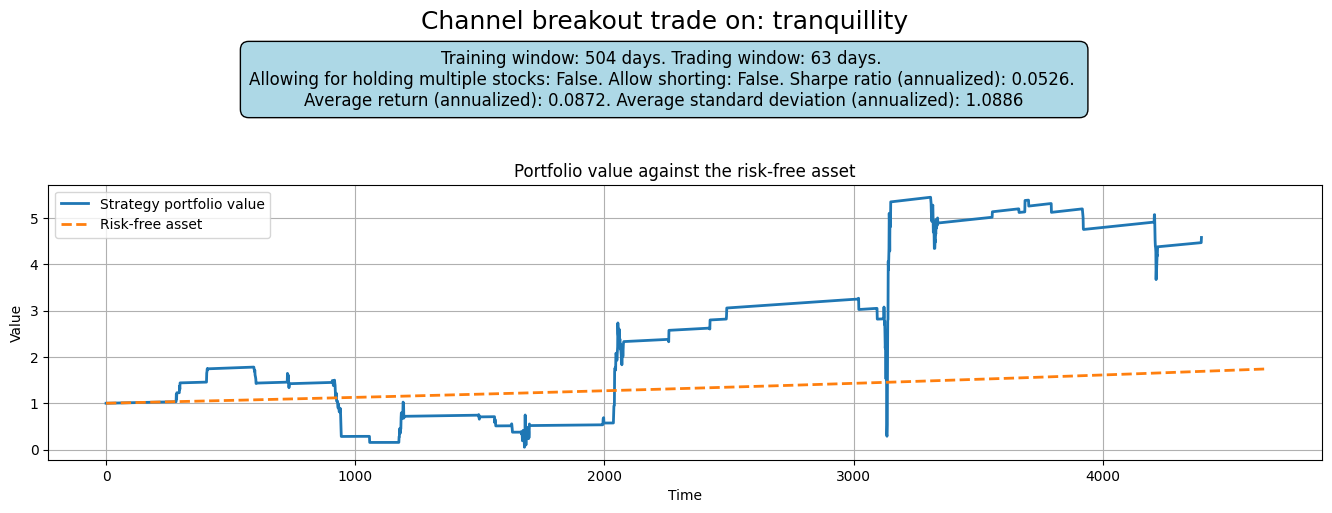

Overall log return of the strategy: 1.5214558649504157


In [ ]:
# Plot everything.
nrows =  1  
height_ratios = [3]

fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(nrows, 1, height_ratios=height_ratios, hspace=0.4)

# Title at the top
fig.suptitle(f"Channel breakout trade on: {asset_name}", fontsize=18)

strategy_returns=strategy_returns[~np.isnan(strategy_returns)] # Take waay any na values when computing mean and std for the text box, when computing the Sharpe Ratio above, we already took care of na values.

# Blue box as a figure-level annotation, not an axes
sharpe_text = (
    f"Training window: {training_period} days. Trading window: {trade_period} days. \n"
    f"Allowing for holding multiple stocks: {allow_multiple_positions}. "
    f"Allow shorting: {allow_short_bool}. Sharpe ratio (annualized): {sharpe_ratio:.4f}. \n"
    f"Average return (annualized): {np.mean(strategy_returns) * 252:.4f}. "
    f"Average standard deviation (annualized): {np.std(strategy_returns) * np.sqrt(252):.4f}"
)
fig.text(
    0.5, 0.9,
    sharpe_text,
    fontsize=12,
    ha='center',
    va='top',
    multialignment='center',
    bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='round,pad=0.5')
)

# Plot starts lower to make room for the text box
ax1 = fig.add_subplot(gs[0])
ax1.set_position([0.06, 0.08, 0.91, 0.55])
ax1.plot(portfolio_value, label='Strategy portfolio value', linewidth=2)
ax1.plot(risk_free_asset, label='Risk-free asset', linestyle='--', linewidth=2)
ax1.set_title("Portfolio value against the risk-free asset")
ax1.set_xlabel("Time")
ax1.set_ylabel("Value")
ax1.legend()
ax1.grid(True)



#plt.savefig("../ChannelBreakoutPlots/CB18.png")
plt.show()



In [ ]:
# Collect results for all assets to put into a table. 
results = []
initial_capital_money_market=1         
training_period = 252*2
trade_period = 63
trade_horizon=len(price_series) # Use all data
allow_short_bool = False
allow_multiple_positions = False

for asset_name in df.columns:
    price_series = df[asset_name].values.astype(float)

    portfolio_value, stock_position, money_account = (
        channel_breakout_strategy_with_updated_optimised_params_and_shortened_trade_period(
            time_series=price_series[:trade_horizon],
            training_period=training_period,
            trade_period=trade_period,
            r=r,
            initial_capital_money_market=initial_capital_money_market,
            allow_short_bool=allow_short_bool,
            allow_multiple_positions=allow_multiple_positions
        )
    )

    strategy_returns = log_returns(portfolio_value)
    strategy_returns=strategy_returns[~np.isnan(strategy_returns)] 
    sharpe_ratio = SharpeRatio(strategy_returns, r=r, period=252)
    avg_return = np.mean(strategy_returns) * 252
    std_dev = np.std(strategy_returns) * np.sqrt(252)

    results.append({
        'Asset': asset_name,
        'Sharpe Ratio': sharpe_ratio,
        'Avg Annual Return': avg_return,
        'Annual Std Dev': std_dev
    })
    print(f"{asset_name} done.")

results_df = pd.DataFrame(results)
print(results_df)

/var/folders/0x/zd5rqg451_530rdy48v7l4b80000gn/T/ipykernel_69152/417184695.py:3: RuntimeWarning: invalid value encountered in log
  log_returns=np.log(portfolie_value[1:maturity]/portfolie_value[0:maturity-1])


gurkor done.
guitars done.
slingshots done.
stocks done.
sugar done.
water done.
tranquillity done.
          Asset  Sharpe Ratio  Avg Annual Return  Annual Std Dev
0        gurkor      0.025062           0.036144        0.245166
1       guitars     -0.106397          -0.234509        2.486049
2    slingshots     -0.060396           0.020075        0.164326
3        stocks     -0.082029           0.009685        0.247659
4         sugar      0.204420           0.043212        0.064630
5         water      0.112049           0.044644        0.130689
6  tranquillity      0.052562           0.087217        1.088566
